In [1]:
import torch, random, numpy as np, os
import math
import torch.nn as nn
import torchvision.models
from torch.nn import functional as F
from torchvision.models import resnet34
from scipy.optimize import linear_sum_assignment
from collections import defaultdict

In [2]:
def seed_everything(seed: int = 1337):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(1)

In [3]:
conv_out = torch.randn(2, 256, 20, 20)
print(conv_out.shape)

torch.Size([2, 256, 20, 20])


In [5]:
# get last 2 dims len (20 and 20)
grid_size_h, grid_size_w = conv_out.shape[-2], conv_out.shape[-1]
print(grid_size_h, grid_size_w)

20 20


In [7]:
# create tensors shape=(20)
# tensors have increasing numbers
grid_h = torch.arange(grid_size_h, dtype=torch.float32, device=conv_out.device)
grid_w = torch.arange(grid_size_w, dtype=torch.float32, device=conv_out.device)
print(grid_h.shape)
print(grid_w.shape)

torch.Size([20])
torch.Size([20])


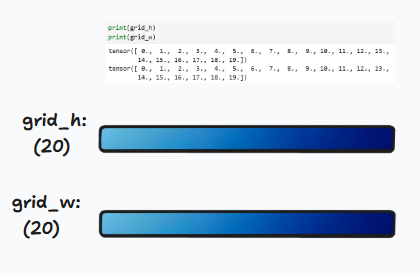

In [23]:
# 2 tensor tuple, each tensor size=(20, 20)
# first tensor has 20 rows filled with same nums (from 0 to 19 rowwise)
# second tensor each row reapiting nums (from 0 to 19 inside each row)
grid = torch.meshgrid(grid_h, grid_w, indexing='ij')
print(grid[0].shape)
print(grid[1].shape)

torch.Size([20, 20])
torch.Size([20, 20])


In [25]:
# concat it to one tensor shape=(2, 20, 20)
grid = torch.stack(grid, dim=0)
print(grid.shape)

torch.Size([2, 20, 20])


In [30]:
grid

tensor([[[ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
           0.,  0.,  0.,  0.,  0.,  0.],
         [ 1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
           1.,  1.,  1.,  1.,  1.,  1.],
         [ 2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,
           2.,  2.,  2.,  2.,  2.,  2.],
         [ 3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,
           3.,  3.,  3.,  3.,  3.,  3.],
         [ 4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,
           4.,  4.,  4.,  4.,  4.,  4.],
         [ 5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,  5.,
           5.,  5.,  5.,  5.,  5.,  5.],
         [ 6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,
           6.,  6.,  6.,  6.,  6.,  6.],
         [ 7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,  7.,
           7.,  7.,  7.,  7.,  7.,  7.],
         [ 8.,  8.,  8.,  8.,  8